In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gautiigiri/oral-dataset/.gitignore
/kaggle/input/datasets/gautiigiri/oral-dataset/lite.ipynb
/kaggle/input/datasets/gautiigiri/oral-dataset/lenet_oral.ipynb
/kaggle/input/datasets/gautiigiri/oral-dataset/requirements.txt
/kaggle/input/datasets/gautiigiri/oral-dataset/lite_ver2.ipynb
/kaggle/input/datasets/gautiigiri/oral-dataset/oral.ipynb
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/266.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/071.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/344.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/228.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/099.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/130.jpeg
/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral C

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold

2026-04-04 13:16:26.563835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775308586.799850      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775308586.863388      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775308587.420509      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775308587.420570      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775308587.420573      17 computation_placer.cc:177] computation placer alr

In [3]:
DATASET_DIR = r"/kaggle/input/datasets/gautiigiri/oral-dataset/Oral Cancer/Oral Cancer Dataset"

IMG_SIZE = 128
CLASSES = ["CANCER", "NON CANCER"]

In [4]:
def resize_with_padding(image, target_size=128):
    h, w = image.shape[:2]

    scale = target_size / max(h, w)
    new_h = int(h * scale)
    new_w = int(w * scale)

    resized = cv2.resize(image, (new_w, new_h))

    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)

    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return canvas

In [5]:
def load_data(directory):
    data = []
    labels = []

    for label, category in enumerate(CLASSES):
        path = os.path.join(directory, category)

        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)

            # Read image
            image = cv2.imread(img_path)

            # Skip if image not loaded
            if image is None:
                print("Skipped:", img_path)
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = resize_with_padding(image, IMG_SIZE)
            image = image / 255.0

            data.append(image)
            labels.append(label)

    return np.array(data), np.array(labels)


In [6]:
X, y = load_data(DATASET_DIR)

print("Total samples:", len(X))

libpng warning: iCCP: extra compressed data


Total samples: 750


In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []

In [8]:
histories = []

In [9]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"\n🔥 Fold {fold+1}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ==============================
    # MODEL
    # ==============================
    model = models.Sequential()

    model.add(layers.Input(shape=(128,128,3)))

    model.add(layers.Conv2D(6, (5,5), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    model.add(layers.Conv2D(16, (5,5), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    model.add(layers.Conv2D(32, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(120, activation='relu'))
    model.add(layers.Dense(84, activation='relu'))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # ==============================
    # TRAIN
    # ==============================
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )
    histories.append(history)

    # ==============================
    # EVALUATE
    # ==============================
    loss, acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

    fold_accuracies.append(acc)


🔥 Fold 1


2026-04-04 13:17:06.392219: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 237ms/step - accuracy: 0.6033 - loss: 0.6603 - val_accuracy: 0.6667 - val_loss: 0.6214
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.6628 - loss: 0.6170 - val_accuracy: 0.6933 - val_loss: 0.5829
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.7020 - loss: 0.5784 - val_accuracy: 0.7667 - val_loss: 0.4772
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.7866 - loss: 0.4961 - val_accuracy: 0.7800 - val_loss: 0.4736
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.8037 - loss: 0.4593 - val_accuracy: 0.8533 - val_loss: 0.4206
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - accuracy: 0.8646 - loss: 0.3972 - val_accuracy: 0.8667 - val_loss: 0.3490
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.8738 - loss: 0.3383 - val_accuracy: 0.8733 - val_loss: 0.3411
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.8803 - loss: 0.3082 - val_accuracy: 0.

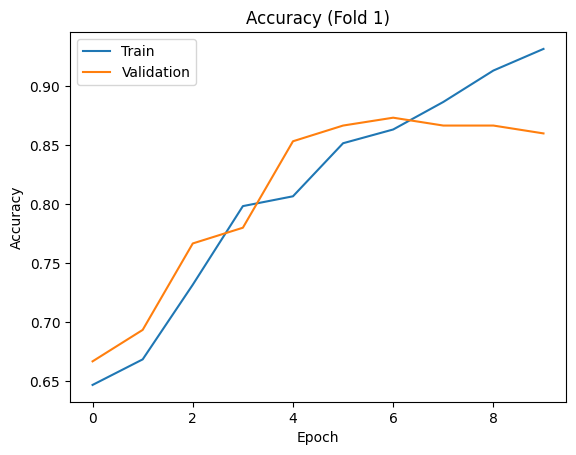

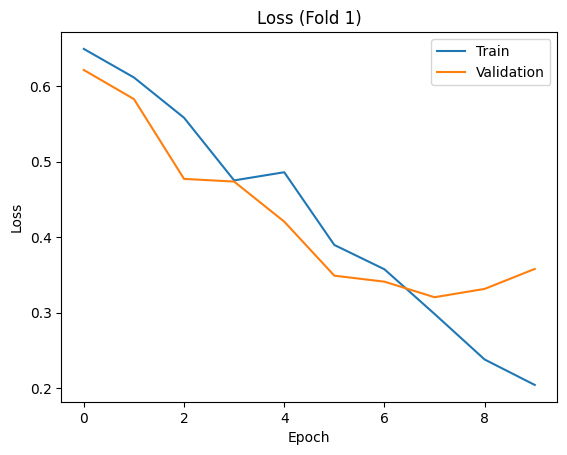

In [10]:
import matplotlib.pyplot as plt

h = histories[0]  # fold 1

plt.plot(h.history['accuracy'])
plt.plot(h.history['val_accuracy'])
plt.title('Accuracy (Fold 1)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.title('Loss (Fold 1)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

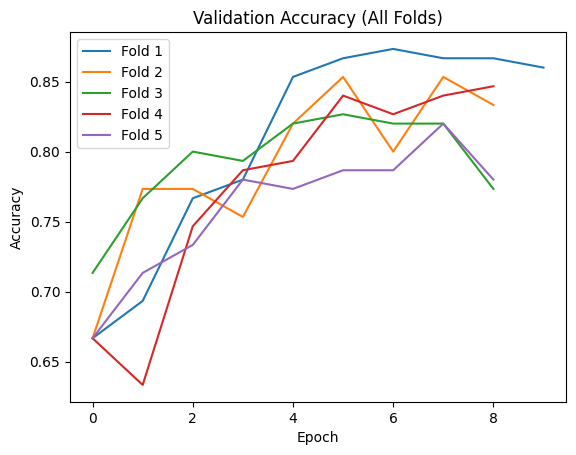

In [11]:
for i, h in enumerate(histories):
    plt.plot(h.history['val_accuracy'], label=f'Fold {i+1}')

plt.title('Validation Accuracy (All Folds)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

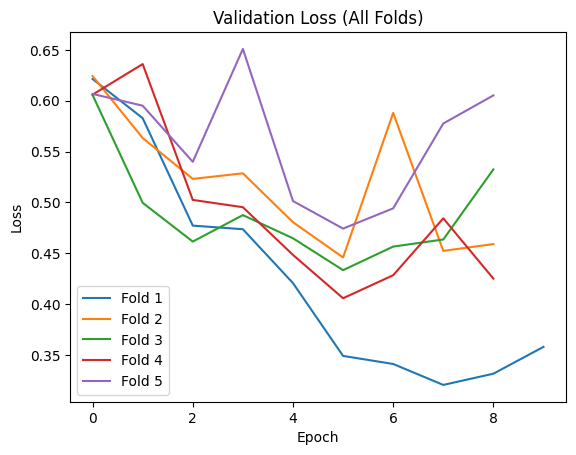

In [12]:
for i, h in enumerate(histories):
    plt.plot(h.history['val_loss'], label=f'Fold {i+1}')

plt.title('Validation Loss (All Folds)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

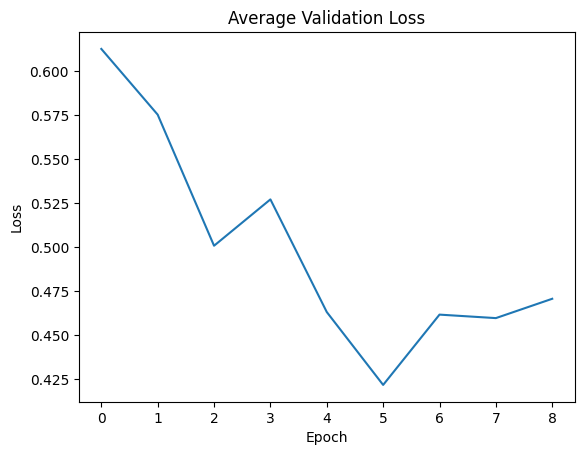

In [13]:

min_epochs = min(len(h.history['val_loss']) for h in histories)

avg_val_loss = np.mean(
    [h.history['val_loss'][:min_epochs] for h in histories],
    axis=0
)

plt.plot(avg_val_loss)

plt.title('Average Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

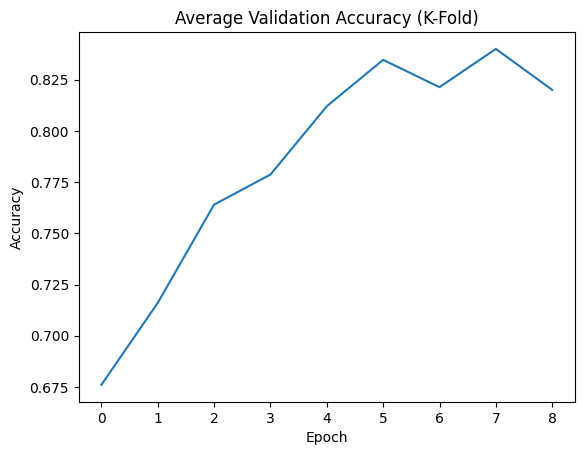

In [14]:
min_epochs = min(len(h.history['val_accuracy']) for h in histories)

# Compute average
avg_val_acc = np.mean(
    [h.history['val_accuracy'][:min_epochs] for h in histories],
    axis=0
)

# Plot
plt.plot(avg_val_acc)

plt.title('Average Validation Accuracy (K-Fold)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()